# 고급 시각화

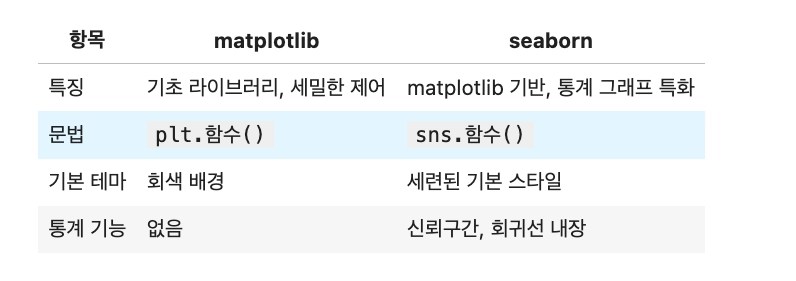

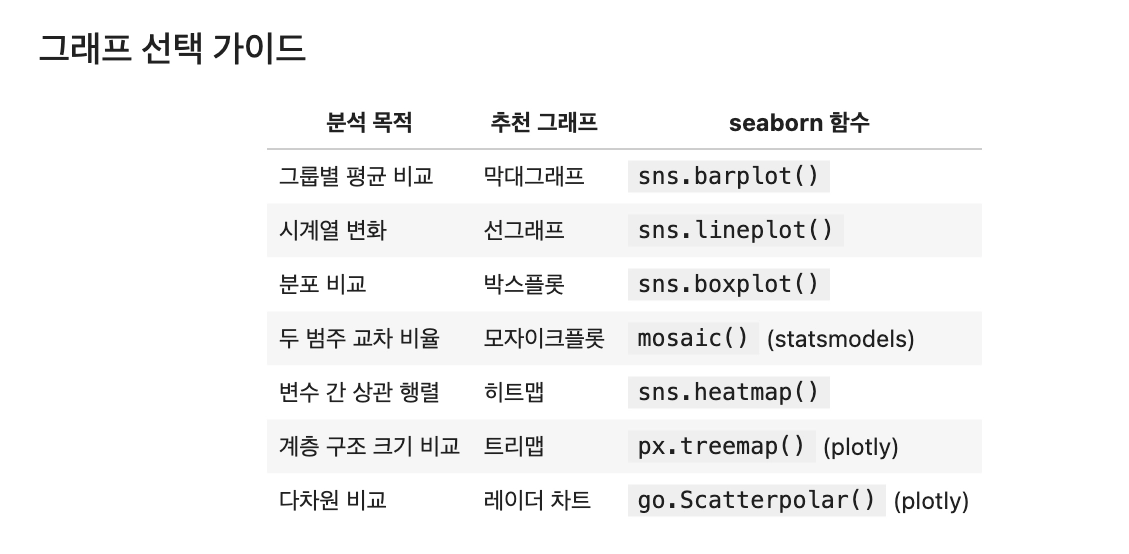

- 공통 환경 설정

In [28]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
print('환경 설정 완료!')

환경 설정 완료!


In [29]:
plt.rcParams['font.family']

['Malgun Gothic']

### seaborn - barplot : 범주형 데이터

In [30]:
# [예제 1] seaborn barplot (code8_1)

df = sns.load_dataset('tips')
print('tips 데이터 앞 3행:')
print(df.shape)
print(df.head(3))


tips 데이터 앞 3행:
(244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


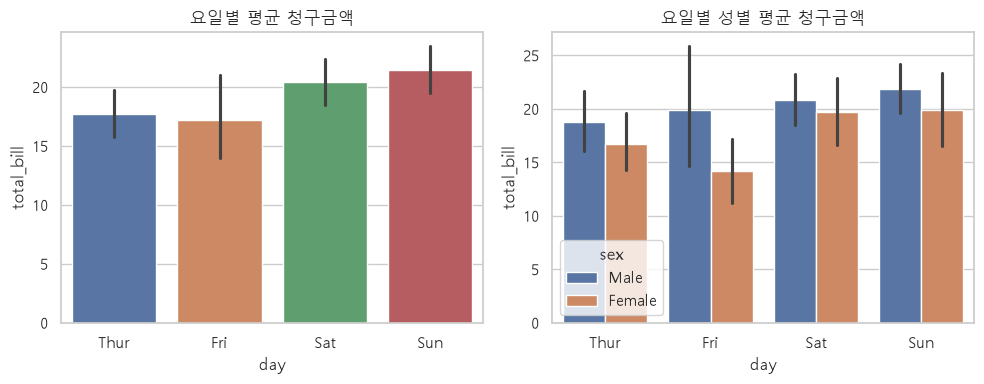

In [31]:
# barplot 생성
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})

# set_theme() 실행 시 자체 font 타입으로 리셋되므로 font 형식을 추가해야함
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2)

# 요일별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='day', legend=False, ax=axes[0])
axes[0].set_title('요일별 평균 청구금액')

# 요일별 성별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='sex', ax=axes[1])
axes[1].set_title('요일별 성별 평균 청구금액')

plt.tight_layout()
plt.show()

In [34]:
# [실습] seaborn - barplot : iris 품종별 평균 꽃잎 길이 
# x: 품종,  y: 꽃잎길이
# font: plt.rcParams['font.family'] = 'Malgun Gothic'

df = pd.read_csv('data/iris.csv')
df.head(3)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa


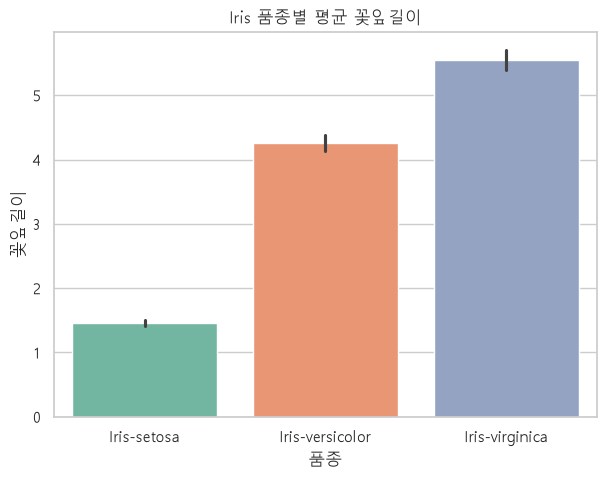

In [37]:
sns.set_theme(style='whitegrid', rc={'figure.figsize': (7, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'

sns.barplot(
    data=df,
    x='Species',
    y='PetalLengthCm',
    estimator='mean',
    hue='Species',
    palette='Set2',
    legend=False
)
plt.title('Iris 품종별 평균 꽃잎길이')
plt.xlabel('품종')
plt.ylabel('꽃잎길이')
plt.show()

### seaborn lineplot — 월별 항공 탑승객

In [39]:
flights = sns.load_dataset('flights')
flights.shape
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


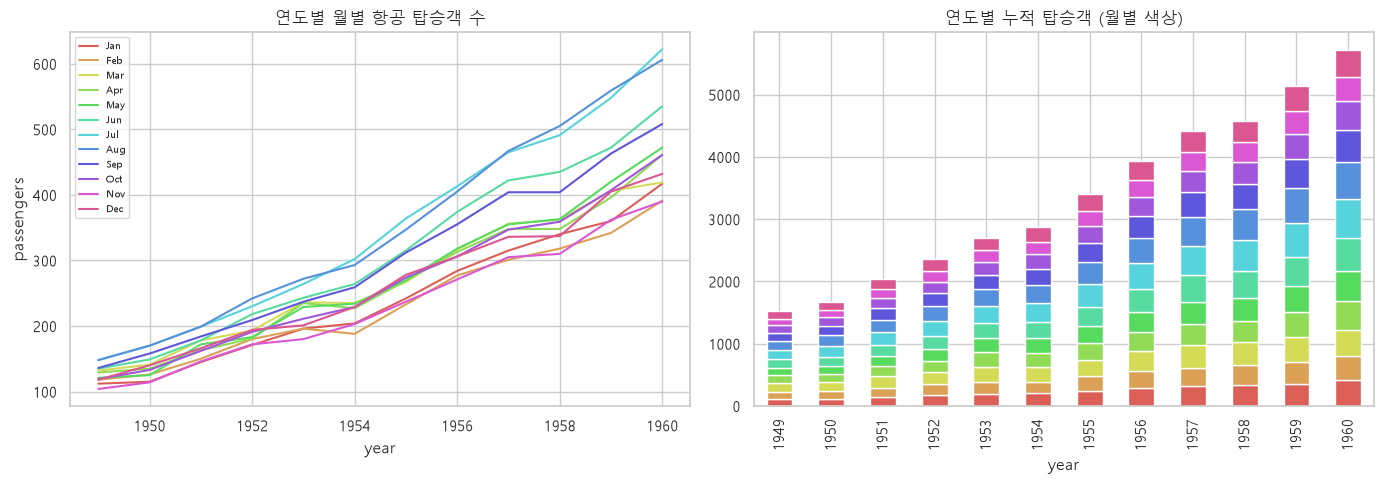

In [40]:
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})
sns.set_palette('hls', 12)

plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 선그래프
sns.lineplot(data=flights, x='year', y='passengers',
             hue='month', ax=axes[0])
axes[0].set_title('연도별 월별 항공 탑승객 수')
axes[0].legend(loc='upper left', fontsize=7)

# 누적 막대그래프
df2 = flights.pivot_table(index='year', columns='month',
                          values='passengers', aggfunc='mean')
df2.plot.bar(stacked=True, ax=axes[1], legend=False)
axes[1].set_title('연도별 누적 탑승객 (월별 색상)')

plt.tight_layout()
plt.show()

### seaborn boxplot — 서울 기온

In [ ]:
# seaborn boxplot — 서울 월별 기온 분포
df = pd.read_csv('data/OBS_ASOS_DD_20250101.csv')
df.head()
df.info()

In [51]:
df['일시'] = pd.to_datetime(df['일시'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   지점        181 non-null    int64         
 1   지점명       181 non-null    object        
 2   일시        181 non-null    datetime64[ns]
 3   평균기온(°C)  181 non-null    float64       
 4   year      181 non-null    int32         
 5   month     181 non-null    int32         
 6   day       181 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(1), object(1)
memory usage: 7.9+ KB


In [50]:
# '일시' 컬럼을 year, month, day 컬럼으로 분리
df['year'] = df['일시'].dt.year
df['month'] = df['일시'].dt.month
df['day'] = df['일시'].dt.day
df.head()
df['month'].value_counts()

month
1    31
3    31
5    31
4    30
6    30
2    28
Name: count, dtype: int64

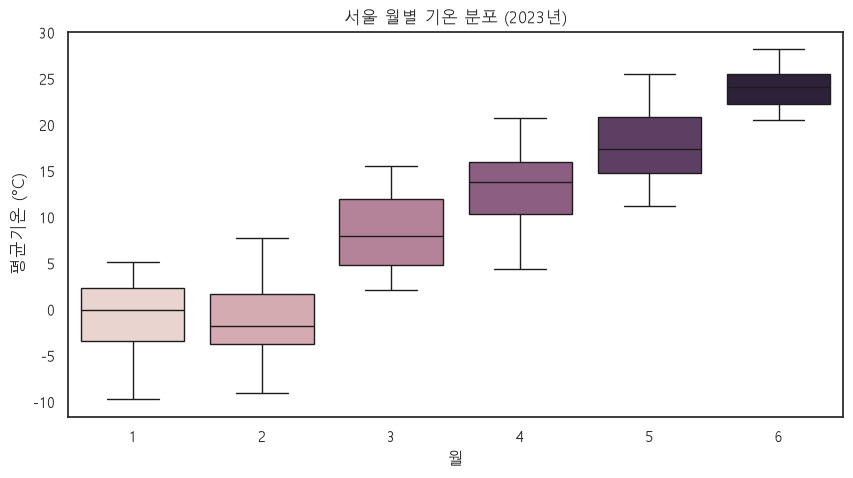

In [58]:
sns.set_theme(style='white', rc={'figure.figsize': (10, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.boxplot(data=df, x='month', y='평균기온(°C)',
            hue='month', legend=False)
sns.color_palette("husl", 9)
plt.title('서울 월별 기온 분포 (2023년)')
plt.xlabel('월')
plt.ylabel('평균기온 (°C)')
plt.show()

In [69]:
# [실습] 2016년 ~ 2025년 까지의 평균 기온, 평균 습도를 boxplot으로 생성하여 한 행에 두 개 그래프 생성
# 년도 기준 그룹
# x : 년도, y : 평균 기온, 평균 습도
# 년도별 박스 색상 다르게 표현
# plt.rcParams['font.family'] = 'Malgun Gothic'

df = pd.read_csv('data/OBS_ASOS_MNH_20260623133953.csv')
# df.info()
df['일시'] = pd.to_datetime(df['일시'])
# df.info()
df['년도'] = df['일시'].dt.year
df.head()
#df['년도'].value_counts()

,지점,지점명,일시,평균기온(°C),평균상대습도(%),평균풍속(m/s),평균지면온도(°C),년도
0,108,서울,2016-01-01,-3.2,53,2.5,-1.4,2016
1,108,서울,2016-02-01,0.2,52,2.8,1.1,2016
2,108,서울,2016-03-01,7.0,51,2.4,9.1,2016
3,108,서울,2016-04-01,14.1,55,2.4,17.0,2016
4,108,서울,2016-05-01,19.6,56,2.4,23.2,2016


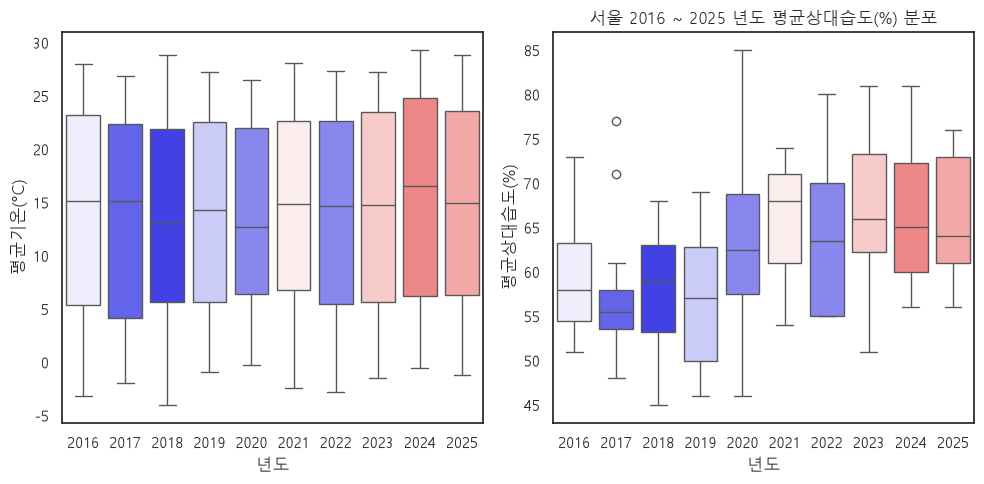

In [73]:
fig, axes = plt.subplots(1, 2)

# 월별 평균 순위 → 색상 맵
month_avg = df.groupby('년도')['평균기온(°C)'].mean()
rank_idx = month_avg.rank().astype(int) - 1
mycolor = sns.color_palette('bwr', 12)
palette = {m: mycolor[r] for m, r in zip(rank_idx.index, rank_idx.values)}


# 평균 기온
sns.set_theme(style='white', rc={'figure.figsize': (10, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.boxplot(data=df, 
            x='년도', 
            y='평균기온(°C)',
            hue='년도', 
            legend=False,
            ax = axes[0],
           palette= palette)

plt.title('서울 2016 ~ 2025 년도 기온 분포')
plt.xlabel('년도')
plt.ylabel('평균기온 (°C)')

# 평균 습도
sns.set_theme(style='white', rc={'figure.figsize': (10, 5)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.boxplot(data=df, 
            x='년도', 
            y='평균상대습도(%)',
            hue='년도', 
            legend=False,
            ax = axes[1],
palette= palette
)

plt.title('서울 2016 ~ 2025 년도 평균상대습도(%) 분포')
plt.xlabel('년도')
plt.ylabel('평균상대습도(%)')

plt.tight_layout()
plt.show()

### seaborn scatterplot 버블 차트 — 범죄율

In [74]:
df = pd.read_csv('data/crimeRatesByState2005.csv')
print('컬럼:', df.columns.tolist())
print(df.head(3))


컬럼: ['state', 'murder', 'forcible_rape', 'robbery', 'aggravated_assault', 'burglary', 'larceny_theft', 'motor_vehicle_theft', 'population']
     state  murder  forcible_rape  robbery  aggravated_assault  burglary  \
0  Alabama     8.2           34.3    141.4               247.8     953.8   
1   Alaska     4.8           81.1     80.9               465.1     622.5   
2  Arizona     7.5           33.8    144.4               327.4     948.4   

   larceny_theft  motor_vehicle_theft  population  
0         2650.0                288.3     4545049  
1         2599.1                391.0      669488  
2         2965.2                924.4     5974834  


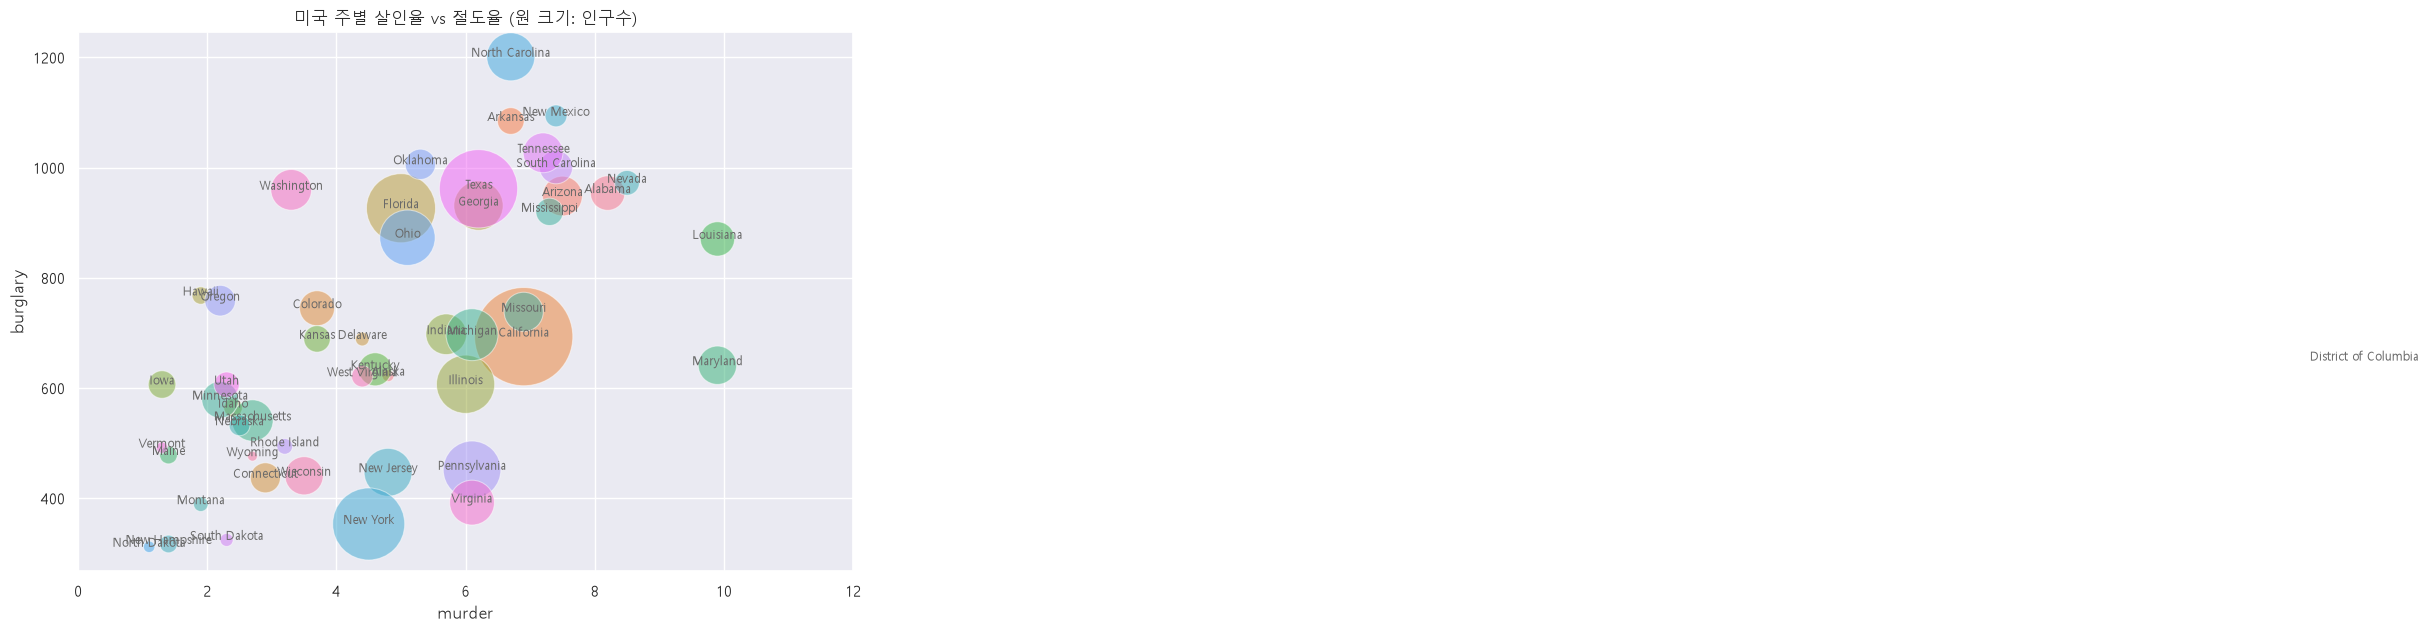

In [81]:
sns.set_theme(rc={'figure.figsize': (10, 7)})
plt.rcParams['font.family'] = 'Malgun Gothic'
sns.scatterplot(data=df, 
                x='murder', 
                y='burglary',
                size='population', 
                sizes=(50, 5000),
                hue='state', 
                alpha=0.5, 
                legend=False)
plt.xlim(0, 12)
plt.title('미국 주별 살인율 vs 절도율 (원 크기: 인구수)')

# 주 이름 레이블
for i in range(len(df)):
    plt.text(df.murder.iloc[i], df.burglary.iloc[i], df.state.iloc[i],
             ha='center', size='x-small', color='dimgray')
plt.show()

### mosaic plot — 타이타닉 생존율

In [82]:
from statsmodels.graphics.mosaicplot import mosaic

In [86]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [88]:
df.shape
df = df.replace({'survived': {0: '사망', 1: '생존'}})
df = df.replace({'sex': {'male': '남성', 'female': '여성'}})

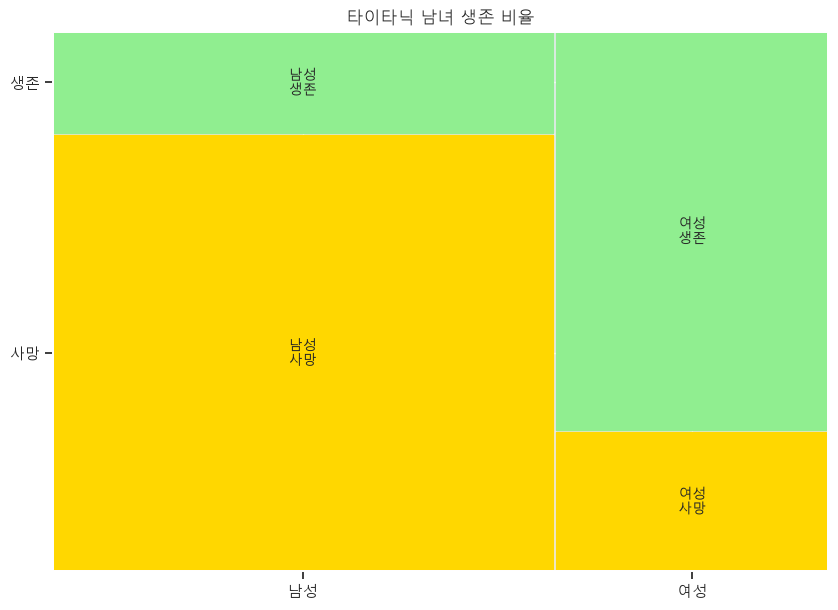

In [90]:
props = lambda key: {'color': 'lightgreen' if '생존' in key else 'gold'}

mosaic(data=df.sort_values('sex'),
       index=['sex', 'survived'],
       properties=props,
       axes_label=True,
       title='타이타닉 남녀 생존 비율')
plt.show()

### seaborn heatmap — 항공 탑승객

In [91]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [92]:
pivot = flights.pivot_table(index='month', columns='year',
                            values='passengers', aggfunc='mean')
pivot

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


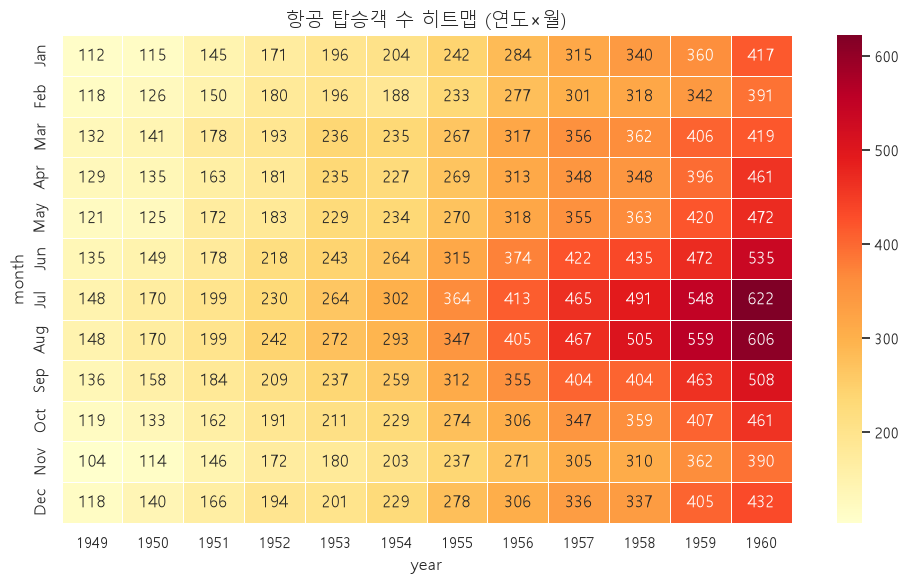

In [93]:
sns.set_theme(rc={'figure.figsize': (10, 6)})
plt.rcParams['font.family'] = 'Malgun Gothic'

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('항공 탑승객 수 히트맵 (연도×월)', fontsize=14)
plt.tight_layout()
plt.show()

### plotly treemap — 국가별 인구/GNI

In [ ]:
ㄹ